# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [9]:
import pandas as pd# importar librerías

In [10]:
# leer conjuntos de datos en los DataFrames


In [11]:
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';') # mostrar información del DataFrame

In [12]:
products = pd.read_csv('/datasets/products.csv', sep=';') # mostrar información del DataFrame# mostrar información del DataFrame

In [13]:
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
 # mostrar información del DataFrame

In [14]:
aisles = pd.read_csv('/datasets/aisles.csv', sep=';') # mostrar información del DataFrame

In [15]:
departments = pd.read_csv('/datasets/departments.csv', sep=';')


## Conclusiones

Para llamar las librerias de panda, imaginando que tienen tabulaciones, entinces considerando eso se usa el separador de tab, 't'

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos:

Se deben de verificar que las columnas de ID, además de las horas (hours of the day) sean enteros,  condf['order_id'] = df['order_id'].astype('int')

Ahora para identificar y completar valores ausentes se eliminan filas, completar la mdeia, moda, de los valores. 

Por último se identifican los duplicados y se eliminan intentado una formula como esta
duplicados = df.duplicated() *aqui es df el que se sustiutye dependeindo que corresponda

print(f"Número de peidos duplicados: {duplicados.sum()}")

df_limpio = df.drop_duplicates()

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [17]:
# Revisa si hay pedidos duplicados
pedidos_duplicados = orders[orders.duplicated(keep=False)]
print(pedidos_duplicados)
print(f"Número de pedidos duplicados: {orders.duplicated(keep=False).sum()}")


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
30371    1918001   188546            14          3                  2   
99462     794638    50898            24          3                  2   
119251    408114    68324             4          3                  2   
142258   2845099    31189            11          3                  2   
145574    794638    50898            24          3                  2   
164581   1112182   202304            84          3                  2   
200059   1782114   106752             1          3                  2   
204042   2125197    14050            48          3                  2   
215294   2160484   107525            16          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
242618   1021560    53767             3          3                  2   
250626    467134    63189            21          3 

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?
si hay, en miercoles y las 2:00m

In [18]:

# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
pedidos_miercoles_2am = orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)]
print(f"Total de pedidos miércoles 2AM: {len(pedidos_miercoles_2am)}")
print("\nPrimeros pedidos:")
print(pedidos_miercoles_2am.head(10))

print(pedidos_miercoles_2am[['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day']])


Total de pedidos miércoles 2AM: 121

Primeros pedidos:
       order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838    2766110   162084            41          3                  2   
5156    2190225   138285            18          3                  2   
15506    553049    58599            13          3                  2   
18420    382357   120200            19          3                  2   
24691    690242    77357             2          3                  2   
25376   1378085    75705            21          3                  2   
26301   2846262   176827             2          3                  2   
29129    353088    46038             4          3                  2   
30371   1918001   188546            14          3                  2   
31404   1725788   147843            10          3                  2   

       days_since_prior_order  
4838                     16.0  
5156                     11.0  
15506                     7.0  
18420                   

¿Qué sugiere este resultado? Que pueda ser error en el sistema o que no todos los pedidos sean duplicados. Pero vamos a eliminarlos

In [19]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates()

In [20]:
# Vuelve a verificar si hay filas duplicadas
print(f"Número total de duplicados restantes: {orders.duplicated(keep=False).sum()}")


Número total de duplicados restantes: 0


In [21]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
duplicados_order_id = orders['order_id'].duplicated().sum()
print(f"Número de order_id duplicado en los pedidos: {duplicados_order_id}")

Número de order_id duplicado en los pedidos: 0


Encontré que en el dia meircoles a las 2 am se realizaron pedidos con algun problema, del cual independiemtente haya sido el mismo, lo que se efectuó fue el quitar los resultados duplicados y continuar con el proyecto.

### `products` data frame

In [22]:
# Verifica si hay filas totalmente duplicadas
productos_duplicados = products[products.duplicated(keep=False)]
print(productos_duplicados)
print(f"Número de productos duplicados: {products.duplicated(keep=False).sum()}")

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []
Número de productos duplicados: 0


In [23]:
# Revisa únicamente si hay ID de productos duplicados

duplicados_product_id = products['product_id'].duplicated().sum()
print(f"Número de product_id duplicados: {duplicados_product_id}")

Número de product_id duplicados: 0


In [24]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)

duplicados_productos = products['product_name'].str.upper().duplicated().sum()
print(f"Número de nombres de productos duplicados: {duplicados_productos}")


Número de nombres de productos duplicados: 1361


In [26]:
# Revisa si hay nombres duplicados de productos no faltantes
productos_nofaltantes = products[products['product_name'].notnull()]['product_name'].str.upper().duplicated().sum()
print(f"Número de nombres de productos no faltantes: {productos_nofaltantes}")
#así tmb funciona
#duplicados_productos = products[products['product_name'].notnull()]['product_name'].str.upper().duplicated().sum()
#print(f"Número de nombres de productos duplicados (no faltantes): {duplicados_productos}")


Número de nombres de productos no faltantes: 104


Tener 104 productos a nombre duplicado puede decir que sean identicos, o una variación como un modelo con diferentes prestaicones o algo así.
Al pirncipio cuando se mostraron los ducplicados y estos fueron 0, no esperaba este outcome.

### `departments` data frame

In [27]:
# Revisa si hay filas totalmente duplicadas

filas_totalmente_duplicadas = departments[departments.duplicated(keep=False)]
print(f"Número de filas totalmente duplicados: {departments.duplicated(keep=False).sum()}")


Número de filas totalmente duplicados: 0


In [28]:
# Revisa únicamente si hay IDs duplicadas de departamentos


duplicados_department_id = departments['department_id'].duplicated().sum()
print(f"Número de department id duplicado en los pedidos: {duplicados_department_id}")




Número de department id duplicado en los pedidos: 0


No fue necesario realizar limpieza de duplicados en la tabla departments
Los datos están listos para el análisis posterior

### `aisles` data frame

In [29]:
# Revisa si hay filas totalmente duplicadas
filas_totalmente_duplicadas_ailes = aisles[aisles.duplicated(keep=False)]
print(f"Número de filas totalmente duplicadas: {aisles.duplicated(keep=False).sum()}")


Número de filas totalmente duplicadas: 0


In [31]:
# Revisa únicamente si hay IDs duplicadas de pasillos
filas_totalmente_duplicadas_id = aisles['aisle_id'].duplicated().sum()  #tenia que modificarlo
print(f"Número de aisles id duplicado en los pedidos: {filas_totalmente_duplicadas_id}")


Número de aisles id duplicado en los pedidos: 0


al no haber filas duplicadas, se dejan como se encuentran

### `order_products` data frame

In [32]:
# Revisa si hay filas totalmente duplicadas
filas_totalmente_duplicadas_order_products = order_products[order_products.duplicated(keep=False)]
print(f"Número de filas totalmente duplicadas: {order_products.duplicated(keep=False).sum()}")

Número de filas totalmente duplicadas: 0


In [33]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
duplicados_order_product = order_products[['order_id', 'product_id']].duplicated().sum()
print(f"Número de combinaciones order_id + product_id duplicadas: {duplicados_order_product}")

Número de combinaciones order_id + product_id duplicadas: 0


no existen duplicados, por lo que se procede con el programa

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [34]:
# Encuentra los valores ausentes en la columna 'product_name'
valores_ausentes = products['product_name'].isnull()
print(f"Número de valores ausentes: {valores_ausentes.sum()}")


Número de valores ausentes: 1258


Existen 1258 valores ausentes, lo que puede acontecer a una posible falta de caracteres o contenido en ciertos parametros puede que este faltante.

In [35]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
# Se Filtran los productos con nombres ausentes
productos_sin_nombre = products[products['product_name'].isnull()]

productos_pasillo_100 = productos_sin_nombre[productos_sin_nombre['aisle_id'] == 100] # aqui están todos relacionados con el pasillo ID 100?

print(f"Total de productos sin nombre: {len(productos_sin_nombre)}")
print(f"Productos sin nombre en pasillo 100: {len(productos_pasillo_100)}")
print(f"¿Todos los productos sin nombre están en pasillo 100? {len(productos_sin_nombre) == len(productos_pasillo_100)}")

Total de productos sin nombre: 1258
Productos sin nombre en pasillo 100: 1258
¿Todos los productos sin nombre están en pasillo 100? True


los productos sin nombre están enm el pasillo 100, por lo que se entiende que este pasillo es una falla en donde o no existen nombres o el pasillo está de mas creando una falla en todo el sistema.

In [36]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print("Información detallada de productos sin nombre:") # info de los productos sin nombre

print(productos_sin_nombre[['product_id', 'aisle_id', 'department_id']].head())

Información detallada de productos sin nombre:
     product_id  aisle_id  department_id
37           38       100             21
71           72       100             21
109         110       100             21
296         297       100             21
416         417       100             21


ahora vemos que el pasillo es el mismo pero ahora también que comparten departamento, no puede ser una coincidencia, mas bien un problema de datos faltantes, o sean productos sin clasificar, o no se cargaron bien los datos.

In [42]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
pasillo_100 = aisles[aisles['aisle_id'] == 100]
print("Información del pasillo ID 100:")
print(pasillo_100)
departamento_21 = departments[departments['department_id'] == 21]
print("Información del departamento ID 21:")
print(departamento_21)

print("Resumen de productos sin nombre:")
print(f"- Pasillo ID 100: {pasillo_100['aisle'].values[0] if len(pasillo_100) > 0 else 'No encontrado'}")
print(f"- Departamento ID 21: {departamento_21['department'].values[0] if len(departamento_21) > 0 else 'No encontrado'}")
print(f"- Total de productos afectados: {len(productos_sin_nombre)}")


productos_pasillo_100 = products[products['aisle_id'] == 100]
productos_depto_21 = products[products['department_id'] == 21]

print(f"Total de productos en pasillo 100: {len(productos_pasillo_100)}")
print(f"Total de productos en departamento 21: {len(productos_depto_21)}")
print(f"¿Todos los productos del pasillo 100 no tienen nombre? {len(productos_pasillo_100) == len(productos_sin_nombre)}")


Información del pasillo ID 100:
    aisle_id    aisle
99       100  missing
Información del departamento ID 21:
    department_id department
20             21    missing
Resumen de productos sin nombre:
- Pasillo ID 100: missing
- Departamento ID 21: missing
- Total de productos afectados: 1258
Total de productos en pasillo 100: 1258
Total de productos en departamento 21: 1258
¿Todos los productos del pasillo 100 no tienen nombre? True


El pasillo 100 y departamento 21 pueden ser categorías creadas específicamente para productos sin clasificar o con datos incompletos, tal vez ya no estén en stock, solo sea como una papelera de reciclaje viendolo en terminos de windows..

In [44]:
# Completa los nombres de productos ausentes con 'Unknown'
print(f"Valores ausentes antes de completar: {products['product_name'].isnull().sum()}")
products['product_name'] = products['product_name'].fillna('Unknown')

print(f"Valores ausentes después de completar: {products['product_name'].isnull().sum()}") #verificación de la completición de los datos

Valores ausentes antes de completar: 1258
Valores ausentes después de completar: 0


ya no están los valores ausentes después de utlizar unknown de forma eficaz.

### `orders` data frame

In [50]:
# Encuentra los valores ausentes
print(f"Valores ausentes en orders:")
print(orders.isnull().sum())

Valores ausentes en orders:
order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [51]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
valores_ausentes_no_primer_pedido = orders[
    (orders['days_since_prior_order'].isnull()) & 
    (orders['order_number'] != 1)
] 
#  así para q no sean del primer pedido (order_number != 1)
print(f"Valores ausentes en days_since_prior_order que NO son primer pedido: {len(valores_ausentes_no_primer_pedido)}")
# Verificando si hay valores ausentes en days_since_prior_order 


Valores ausentes en days_since_prior_order que NO son primer pedido: 0


Esto no sdice que los primeros pedidos corresponden a la priemra orden del cliente donde no hay errores en los datos y estos valores ausentes tieenn explicación logica.

### `order_products` data frame

In [52]:
# Encuentra los valores ausentes
print(f"Valores ausentes en order_products:")
print(order_products.isnull().sum())


Valores ausentes en order_products:
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [54]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print("Estadísticas descriptivas de 'add_to_cart_order':")
print(order_products['add_to_cart_order'].describe()) #esto con las estadísticas, pero 

print(f"Valor mínimo en 'add_to_cart_order': {order_products['add_to_cart_order'].min()}")
print(f"Valor máximo en 'add_to_cart_order': {order_products['add_to_cart_order'].max()}")


Estadísticas descriptivas de 'add_to_cart_order':
count    4.544171e+06
mean     8.351669e+00
std      7.080368e+00
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.100000e+01
max      6.400000e+01
Name: add_to_cart_order, dtype: float64
Valor mínimo en 'add_to_cart_order': 1.0
Valor máximo en 'add_to_cart_order': 64.0


Se confirma como el producto tien el valor minimo de 1 lo cual debe ser bueno, el maximo significa que alguien obtuvo 64

In [57]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
pedidos_con_valores_ausentes = order_products[order_products['add_to_cart_order'].isnull()]['order_id']
print(pedidos_con_valores_ausentes)


737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [59]:

# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
pedidos_con_ausentes = order_products[order_products['add_to_cart_order'].isnull()]
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
conteo_productos_por_pedido = pedidos_con_ausentes.groupby('order_id')['product_id'].count()
print(f"Número de pedidos con valores ausentes: {len(conteo_productos_por_pedido)}")
print(f"Número mínimo de productos en estos pedidos: {conteo_productos_por_pedido.min()}")
print(f"Número máximo de productos en estos pedidos: {conteo_productos_por_pedido.max()}")
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
todos_mas_de_64 = (conteo_productos_por_pedido > 64).all()
print(f"¿Todos los pedidos con valores ausentes tienen más de 64 productos? {todos_mas_de_64}")


Número de pedidos con valores ausentes: 70
Número mínimo de productos en estos pedidos: 1
Número máximo de productos en estos pedidos: 63
¿Todos los pedidos con valores ausentes tienen más de 64 productos? False


ningun pedido tiene mas de 64 productos, pero puede ser problemas tecnicos cualquier causa, hay 836 filas con valores ausentes pero solo 70 pedidos únicos, por lo que cada pedido afectado tiene múltiples productos sin orden registrado

In [63]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype('int')
print(order_products['add_to_cart_order'])


0          17
1           1
2           1
3          35
4           5
           ..
4545002    12
4545003     9
4545004     4
4545005     8
4545006     9
Name: add_to_cart_order, Length: 4545007, dtype: int64


pues lo que se enceuntra es que y los valore erroneos se convierten a 999 rellenados a enteros para su clasificación,identificando esos productos donde no se registró el orden de agregado como lo son esos 70 pedidos únicos con múltiples productos cada uno.


## Conclusiones

Se eliminan duplicados, en orders 30 pedidos duplicados concentrados específicamente los miércoles a las 2:00 AM, lo que era un posible error sistemático en esa hora, En cuanto a valores ausentes, se detectaron 1,258 productos sin nombre pertenecientes al pasillo ID 100, reemplazandola con Unknown. Los 28,817 valores ausentes en days_since_prior_order correspondían lógicamente a primeros pedidos de clientes y se mantuvieron sin modificar. Tambipen se identificaron 836 valores ausentes en add_to_cart_order distribuidos en 70 pedidos únicos, que fueron reemplazados con 999 para facilitar su identificación posterior y a tipo entero, la tabla products mostró 104 nombres duplicados, estos se interpretaron como posibles variaciones del mismo producto y se conservaron para análisis posteriores.


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [66]:
print("Verificación de rangos en las columnas de tiempo:")
print(f"order_hour_of_day - Mínimo: {orders['order_hour_of_day'].min()}, Máximo: {orders['order_hour_of_day'].max()}")



Verificación de rangos en las columnas de tiempo:
order_hour_of_day - Mínimo: 0, Máximo: 23


In [65]:
print(f"order_dow - Mínimo: {orders['order_dow'].min()}, Máximo: {orders['order_dow'].max()}")


order_dow - Mínimo: 0, Máximo: 6


se ve como los rangos oscilan entre 0 y 23, por lo qye el tiempo ser verá reflejado de esa manera, y los días van de 0-6 lo que corresponde a cada semana.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

Pedidos por hora del día:
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64


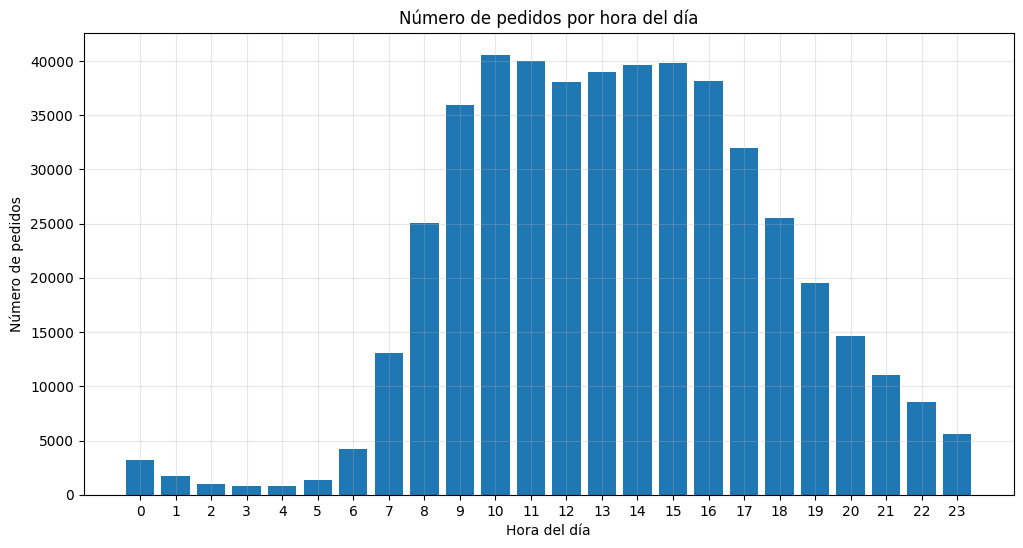

In [68]:
import matplotlib.pyplot as plt

# Primero se calculan los pedidos por hora
pedidos_por_hora = orders['order_hour_of_day'].value_counts().sort_index()
print("Pedidos por hora del día:")
print(pedidos_por_hora)

# para cerar el grafico
plt.figure(figsize=(12, 6))
plt.bar(pedidos_por_hora.index, pedidos_por_hora.values)
plt.title('Número de pedidos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.xticks(range(0, 24))  # Mostrar todas las horas de 0 a 23
plt.grid(True, alpha=0.3)
plt.show()



con ayuda del gráfico se puede ver como en la madrugada por lógica las personas duermen, pero es a las 9 am y en ese pico hasta las 4 pm que es donde se hacen mas pedidos, por lo que también se ve como ese hora de las 9 am es la mas codiciada, pero también se representa de buena manera.

### [A3] ¿Qué día de la semana compran víveres las personas?

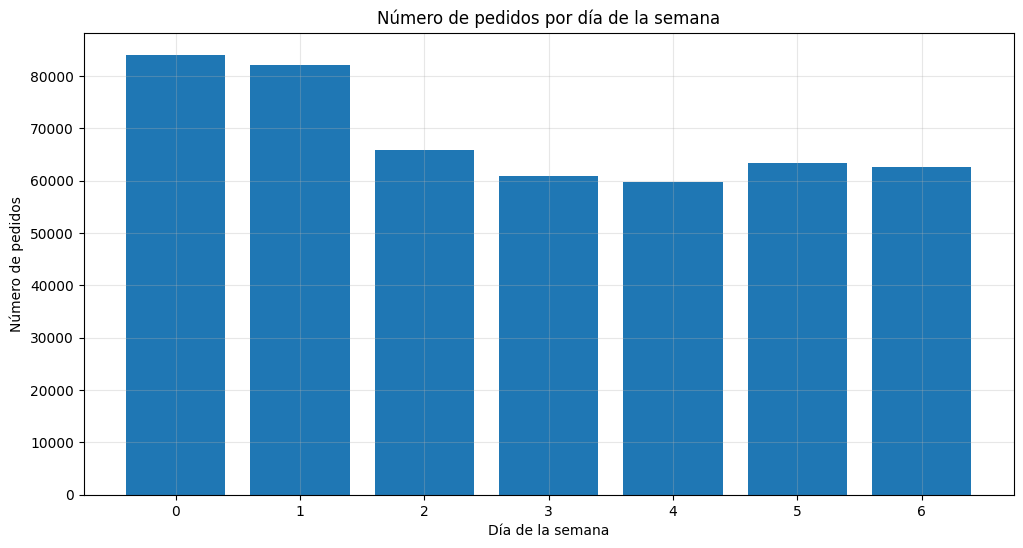

In [69]:
pedidos_por_dia = orders['order_dow'].value_counts().sort_index()
# Para crear el gráfico
plt.figure(figsize=(12, 6))
plt.bar(pedidos_por_dia.index, pedidos_por_dia.values)
plt.title('Número de pedidos por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Número de pedidos')
plt.xticks(range(0, 7))  # Mostrar todos los días de 0-6
plt.grid(True, alpha=0.3)
plt.show()

El día 0 que es Domingo es el día en el que mas pedidos se solicitan, seguido de lunes y teniendo fuerza después de la caida para el jueves. 

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Valor mínimo: 0.0
Valor máximo: 30.0
Promedio: 11.10


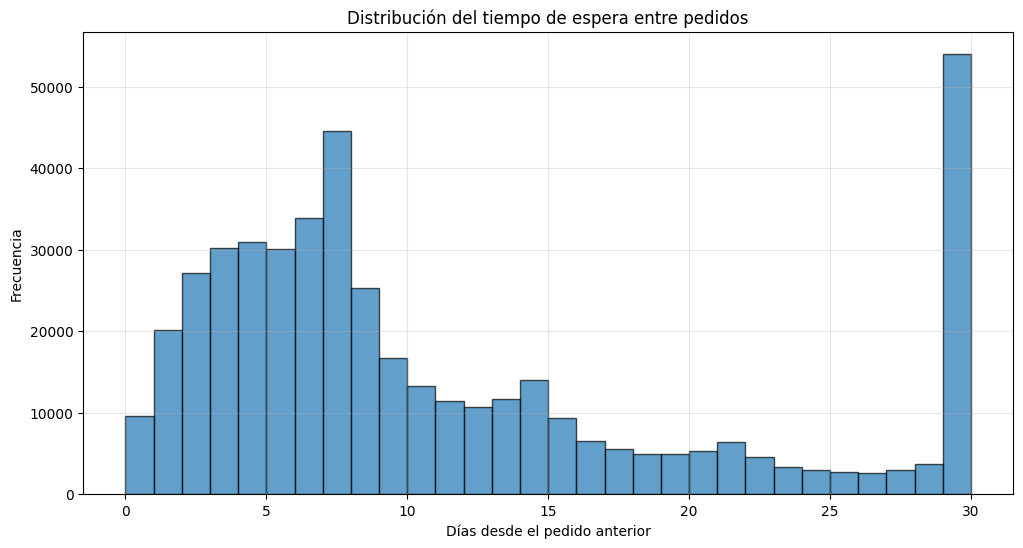

In [70]:
tiempo_espera = orders['days_since_prior_order'].dropna()
print(f"Valor mínimo: {tiempo_espera.min()}")
print(f"Valor máximo: {tiempo_espera.max()}")
print(f"Promedio: {tiempo_espera.mean():.2f}")

# histograma
plt.figure(figsize=(12, 6))
plt.hist(tiempo_espera, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribución del tiempo de espera entre pedidos')
plt.xlabel('Días desde el pedido anterior')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()


El repunte masivo a los 30 días sugiere compras recurrentes mensuales o un límite de registro en el sistema. Los picos secundarios en los días 7 y 14 demuestran un claro hábito de reabastecimiento semanal y quincenal y pocos compran de inmediato; el grueso de los pedidos ocurre orgánicamente entre la primera y segunda semana.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [ ]:
# van los datos filtrando por día


In [ ]:
#tendre q ponerlo en una sola celda

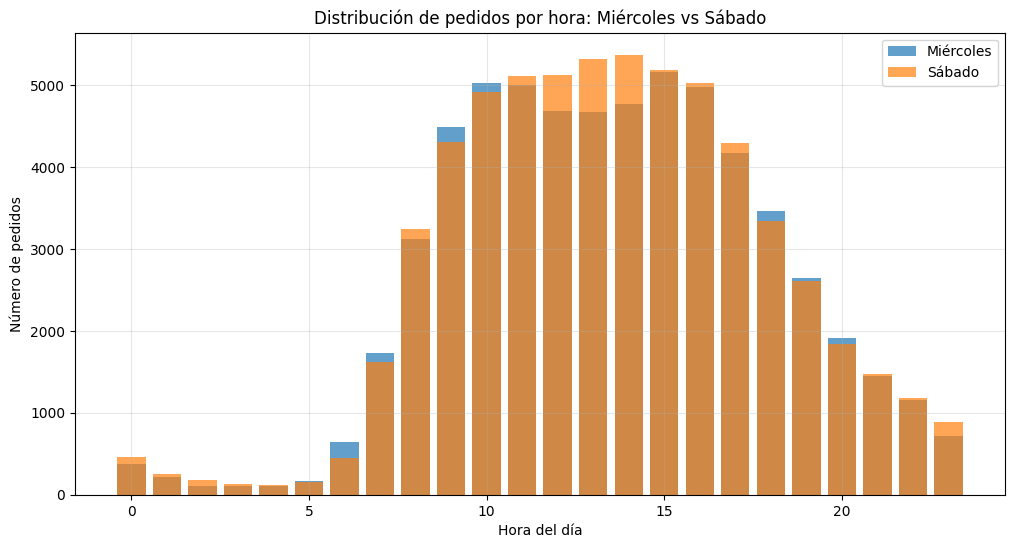

In [72]:
miercoles = orders[orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
sabado = orders[orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(miercoles.index, miercoles.values, alpha=0.7, label='Miércoles')
plt.bar(sabado.index, sabado.values, alpha=0.7, label='Sábado')
plt.title('Distribución de pedidos por hora: Miércoles vs Sábado')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Ambos días comparten un patrón casi idéntico, concentrando su mayor actividad entre las 10:00 y las 15:00 horas. La principal diferencia es sutil: los miércoles registran ligeramente más pedidos durante la mañana (9:00 - 10:00), mientras que los sábados tienen un volumen de ventas un poco mayor por la tarde."

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [ ]:


miercoles = orders[orders['order_number'] == 3]['order_hour_of_day'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(miercoles.index, miercoles.values, alpha=0.7, label='Miércoles')
plt.bar(sabado.index, sabado.values, alpha=0.7, label='Sábado')
plt.title('Distribución de pedidos por hora: Miércoles vs Sábado')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




Escribe aquí tus conclusiones

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

Escribe aquí tus conclusiones

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

Escribe aquí tus conclusiones

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

Escribe aquí tus conclusiones

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

Escribe aquí tus conclusiones

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

Escribe aquí tus conclusiones

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

Escribe aquí tus conclusiones

### Conclusion general del proyecto: